<a href="https://colab.research.google.com/github/vermankit/linear-regression/blob/master/HousePricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [3]:
data = {
    "Size":[800,1000,1200,1500,1800,2000],
    "Price":[150,180,220,280,340,390]
}

df = pd.DataFrame(data)
df

,Size,Price
0,800,150
1,1000,180
2,1200,220
3,1500,280
4,1800,340
5,2000,390


In [5]:
X = df["Size"]
y = df["Price"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [9]:
lr = LinearRegression()

# Reshape X_train to be a 2D array for the LinearRegression model
X_train_reshaped = X_train.values.reshape(-1, 1)

lr.fit(X_train_reshaped, y_train)

LinearRegression()

In [10]:
print("Slope:", lr.coef_)
print("Intercept:", lr.intercept_)

Slope: [0.21020408]
Intercept: -34.08163265306126


In [11]:
prediction = lr.predict([[1600]])

print(prediction)

[302.24489796]


In [13]:
pred = lr.predict(X_test.values.reshape(-1, 1))

print("MSE:", mean_squared_error(y_test,pred))
print("R2:",r2_score(y_test,pred))

MSE: 134.21491045397792
R2: 0.4034892868712092


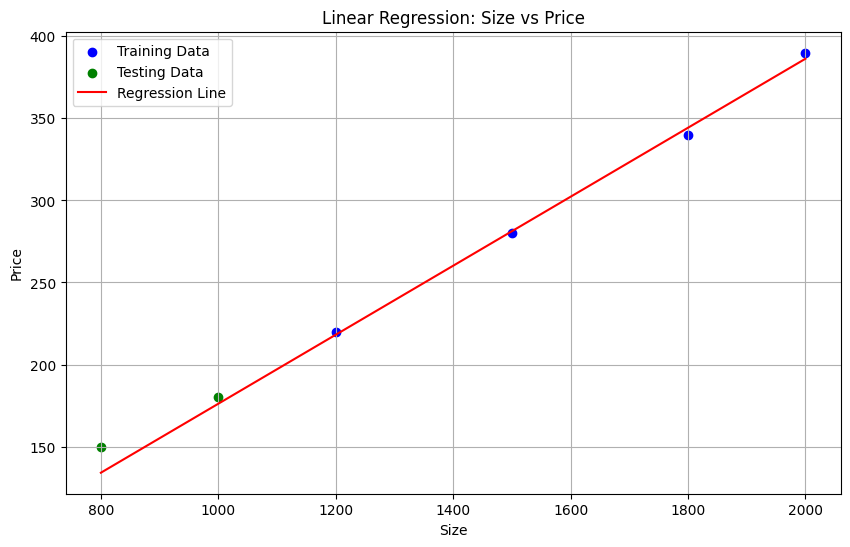

In [15]:
plt.figure(figsize=(10, 6))

# Scatter plot of training data
plt.scatter(X_train, y_train, color='blue', label='Training Data')

# Scatter plot of testing data
plt.scatter(X_test, y_test, color='green', label='Testing Data')

# Plot the regression line
x_line = np.array([df['Size'].min(), df['Size'].max()]).reshape(-1, 1)
y_line = lr.predict(x_line)
plt.plot(x_line, y_line, color='red', label='Regression Line')

plt.title('Linear Regression: Size vs Price')
plt.xlabel('Size')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

Now let's visualize the results of the model with polynomial features.